# Exploratory Data Analysis (EDA)

## Smart Water Treatment System

### Objective

The objective of this notebook is to explore the SWaT dataset and understand the behavior of industrial sensors and actuators before building machine learning models.

This analysis focuses on:

- Dataset overview
- Class distribution
- Sensor behavior
- Correlation analysis
- Outlier detection
- Industrial insights

In [16]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

plt.style.use("ggplot")

pd.set_option("display.max_columns",None)

In [17]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT/"data"/"processed"/"swat_clean_v1.csv"

df = pd.read_csv(DATA_PATH)

df["Timestamp"] = pd.to_datetime(df["Timestamp"])

df.head()

,Timestamp,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,MV201,P201,P202,P203,P204,P205,P206,DPIT301,FIT301,LIT301,MV301,MV302,MV303,MV304,P301,P302,AIT401,AIT402,FIT401,LIT401,P401,P402,P403,P404,UV401,AIT501,AIT502,AIT503,AIT504,FIT501,FIT502,FIT503,FIT504,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,Normal/Attack
0,2015-12-28 10:00:00,2.427057,522.8467,2.0,2,1,262.0161,8.396437,328.6337,2.445391,2.0,1.0,1.0,2,1.0,2,1,19.74838,2.206835,956.1651,1,2,1.0,1,1,2,148.808,156.0882,1.713517,942.0662,1,2,1,1,2,7.878621,145.1166,264.5475,12.03538,1.723789,1.279621,0.735269,0.307786,2,1,250.8652,1.649953,189.5988,0.000128,1,1,1,Normal
1,2015-12-28 10:00:01,2.446274,522.8860,2.0,2,1,262.0161,8.396437,328.6337,2.445391,2.0,1.0,1.0,2,1.0,2,1,19.74838,2.208244,956.1651,1,2,1.0,1,1,2,148.808,156.0882,1.715952,942.0277,1,2,1,1,2,7.878621,145.1166,264.5475,12.03538,1.723789,1.297554,0.735269,0.307786,2,1,250.8652,1.649953,189.6789,0.000128,1,1,1,Normal
2,2015-12-28 10:00:02,2.489191,522.8467,2.0,2,1,262.0161,8.394514,328.6337,2.442316,2.0,1.0,1.0,2,1.0,2,1,19.69076,2.208628,956.4855,1,2,1.0,1,1,2,148.808,156.0882,1.715952,941.8739,1,2,1,1,2,7.878621,145.1166,264.5475,12.03538,1.723404,1.293967,0.735269,0.308619,2,1,250.8812,1.649953,189.6789,0.000128,1,1,1,Normal
3,2015-12-28 10:00:03,2.534350,522.9645,2.0,2,1,262.0161,8.394514,328.6337,2.442316,2.0,1.0,1.0,2,1.0,2,1,19.69076,2.208628,956.8060,1,2,1.0,1,1,2,148.808,156.0882,1.714670,941.7970,1,2,1,1,2,7.878621,145.0141,264.5475,12.03538,1.723404,1.281158,0.735269,0.308619,2,1,250.8812,1.649953,189.6148,0.000128,1,1,1,Normal
4,2015-12-28 10:00:04,2.569260,523.4748,2.0,2,1,262.0161,8.394514,328.6337,2.443085,2.0,1.0,1.0,2,1.0,2,1,19.69076,2.208628,957.0864,1,2,1.0,1,1,2,148.808,156.0882,1.714670,942.2200,1,2,1,1,2,7.878621,144.8859,264.5475,12.03538,1.723404,1.281158,0.735269,0.308619,2,1,250.8812,1.649953,189.5027,0.000128,1,1,1,Normal


# Dataset Overview

Before exploring the sensors, we first examine the dataset structure.

In [18]:
print("Rows :",df.shape[0])
print("Columns :",df.shape[1])

df.info()

Rows : 1441719
Columns : 53
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1441719 entries, 0 to 1441718
Data columns (total 53 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Timestamp      1441719 non-null  datetime64[ns]
 1   FIT101         1441719 non-null  float64       
 2   LIT101         1441719 non-null  float64       
 3   MV101          449919 non-null   float64       
 4   P101           1441719 non-null  int64         
 5   P102           1441719 non-null  int64         
 6   AIT201         449919 non-null   float64       
 7   AIT202         1441719 non-null  float64       
 8   AIT203         1441719 non-null  float64       
 9   FIT201         1441719 non-null  float64       
 10  MV201          449919 non-null   float64       
 11  P201           449919 non-null   float64       
 12  P202           449919 non-null   float64       
 13  P203           1441719 non-null  int64         
 14  P204  

# Target Distribution

This section investigates the balance between normal operation and attack scenarios.

In [19]:
class_counts = df["Normal/Attack"].value_counts()

class_counts

Normal/Attack
Normal    1387098
Attack      54621
Name: count, dtype: int64

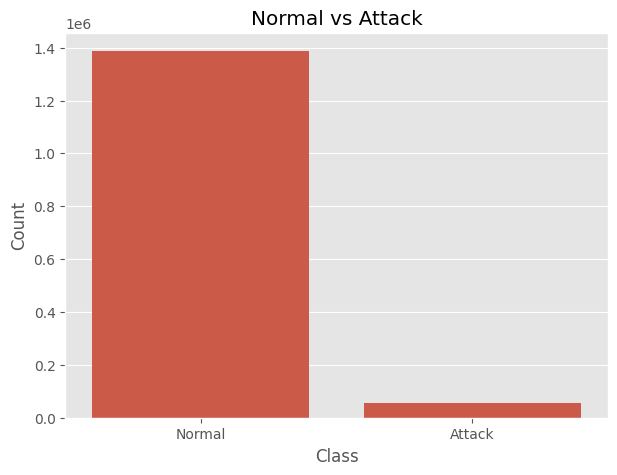

In [20]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values
)

plt.title("Normal vs Attack")

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()

### Observation

The dataset contains both normal and attack samples.

This allows the problem to be formulated as a supervised binary classification task.

# Missing Values Analysis

Missing values are common in industrial systems.

They may represent inactive sensors rather than corrupted data.

In [21]:
missing = (
    df.isnull()
    .mean()*100
).sort_values(ascending=False)

missing = missing[missing>0]

missing.head(20)

MV201     68.792879
MV101     68.792879
P204      68.792879
AIT201    68.792879
MV303     68.792879
P202      68.792879
P201      68.792879
dtype: float64

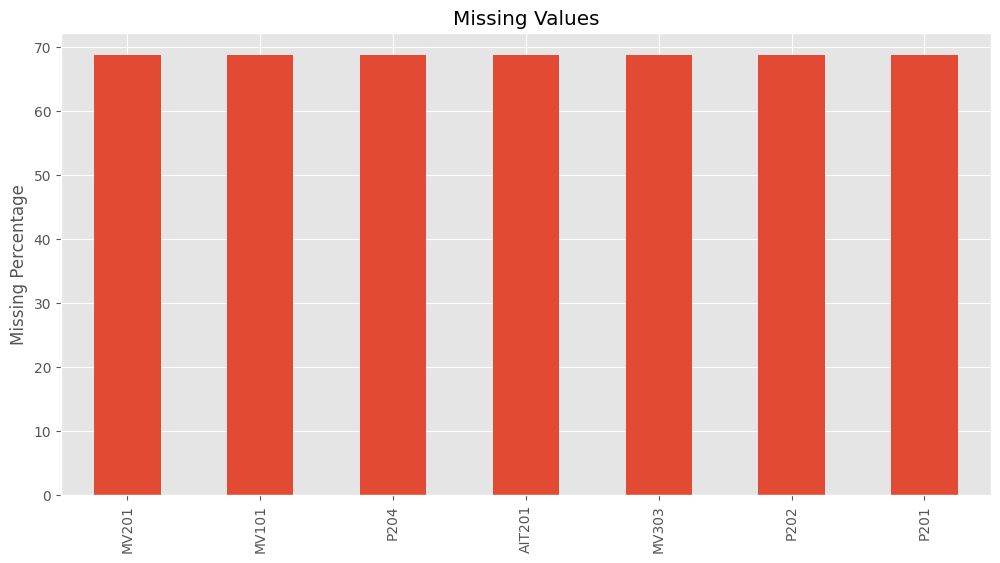

In [22]:
plt.figure(figsize=(12,6))

missing.plot(kind="bar")

plt.ylabel("Missing Percentage")

plt.title("Missing Values")

plt.show()

High missing values do not necessarily indicate poor data quality.

Further investigation is required before removing any feature.

# Industrial Sensor Categories

The sensors are grouped according to their industrial function.

In [23]:
flow = [
"FIT101",
"FIT201",
"FIT301",
"FIT401",
"FIT501"
]

level = [
"LIT101",
"LIT301",
"LIT401"
]

pressure = [
"PIT501",
"PIT502",
"DPIT301"
]

quality = [
"AIT201",
"AIT202",
"AIT203"
]

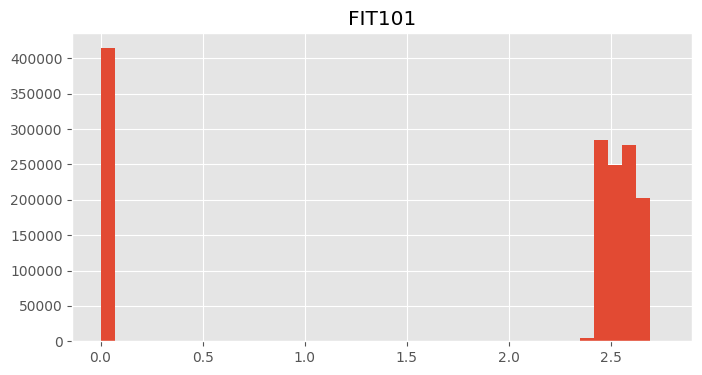

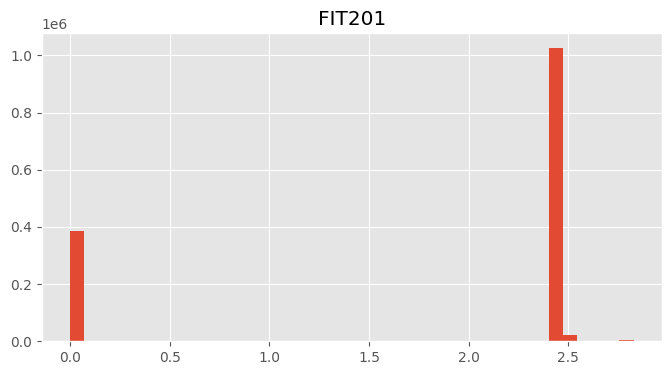

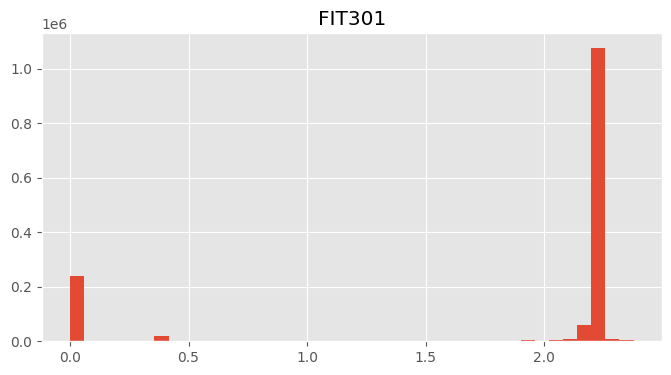

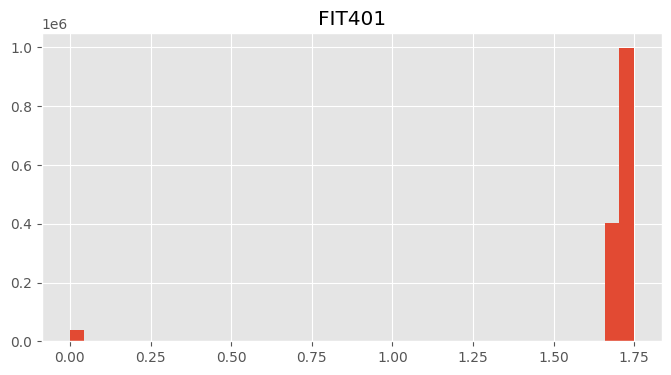

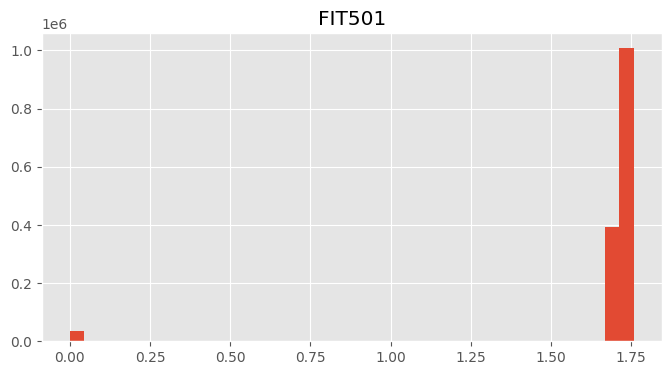

In [24]:
for sensor in flow:

    plt.figure(figsize=(8,4))

    plt.hist(df[sensor].dropna(),bins=40)

    plt.title(sensor)

    plt.show()

### Industrial Insight

Flow sensors measure the water flow rate.

Large deviations may indicate pump malfunction, valve problems, or abnormal process conditions.

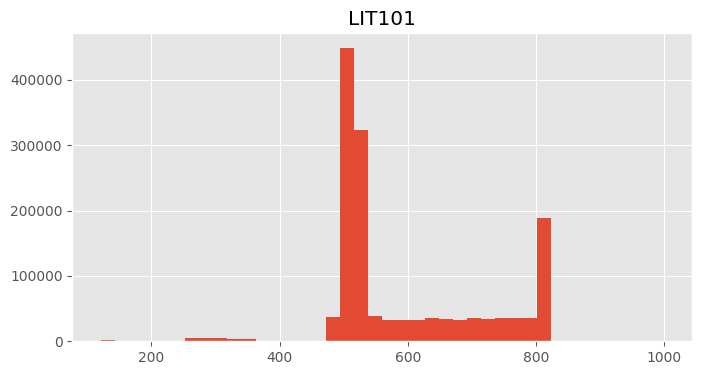

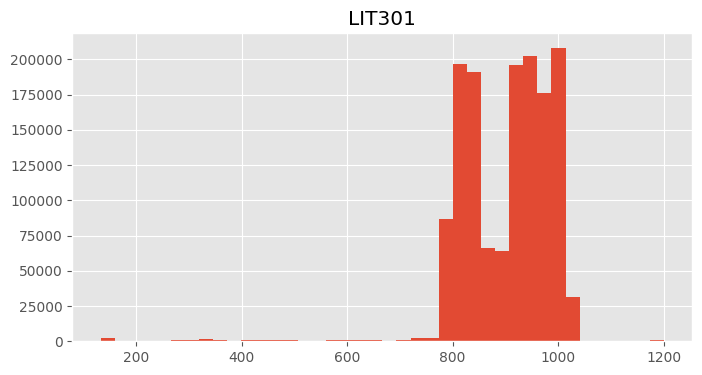

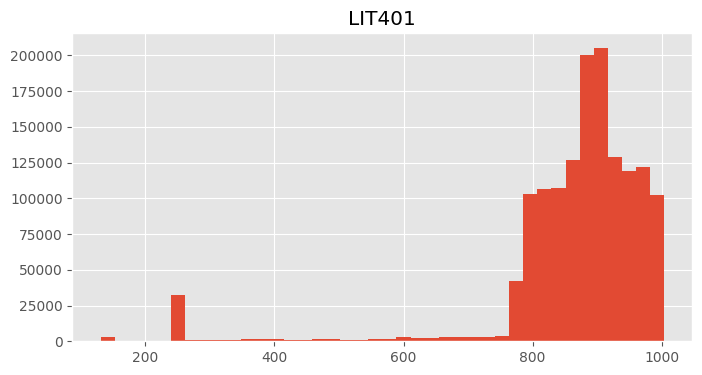

In [25]:
for sensor in level:

    plt.figure(figsize=(8,4))

    plt.hist(df[sensor].dropna(),bins=40)

    plt.title(sensor)

    plt.show()

Level sensors monitor storage tanks.

Rapid changes may indicate abnormal operation.

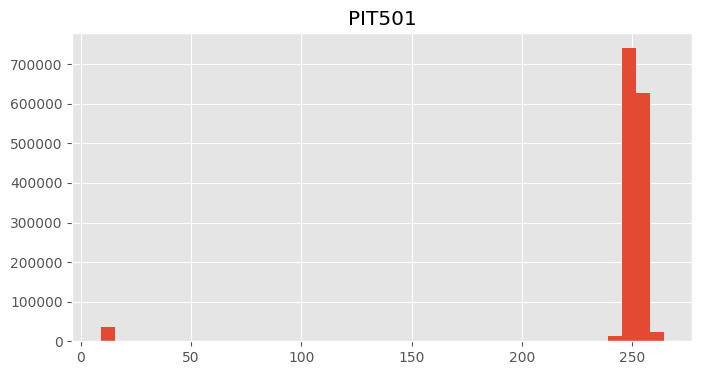

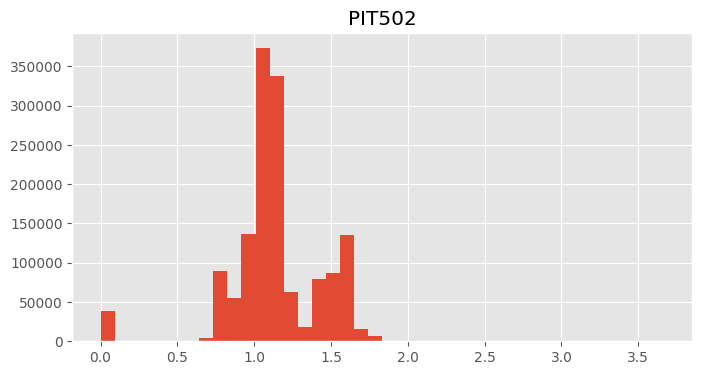

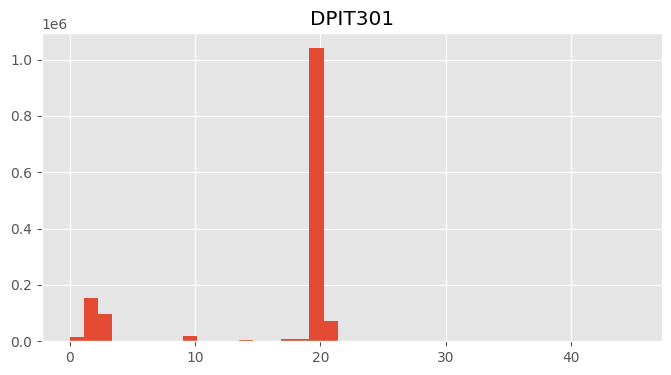

In [26]:
for sensor in pressure:

    plt.figure(figsize=(8,4))

    plt.hist(df[sensor].dropna(),bins=40)

    plt.title(sensor)

    plt.show()

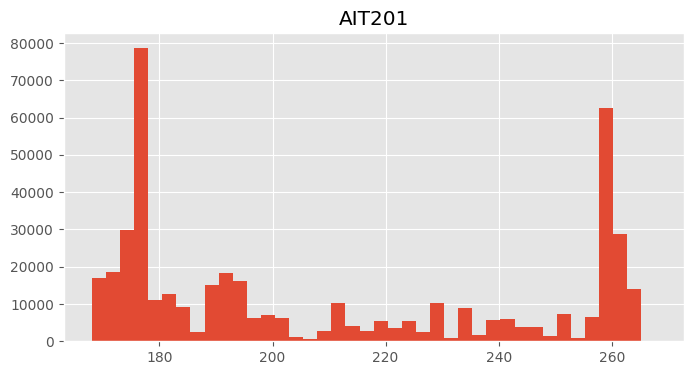

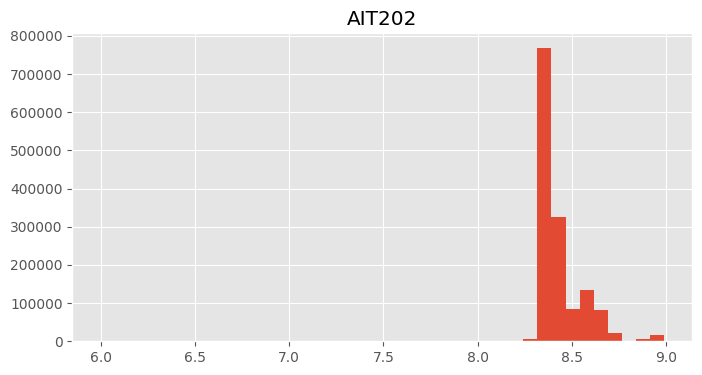

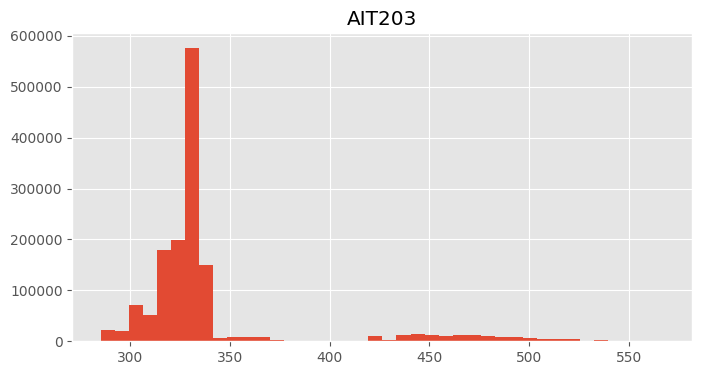

In [27]:
for sensor in quality:

    plt.figure(figsize=(8,4))

    plt.hist(df[sensor].dropna(),bins=40)

    plt.title(sensor)

    plt.show()

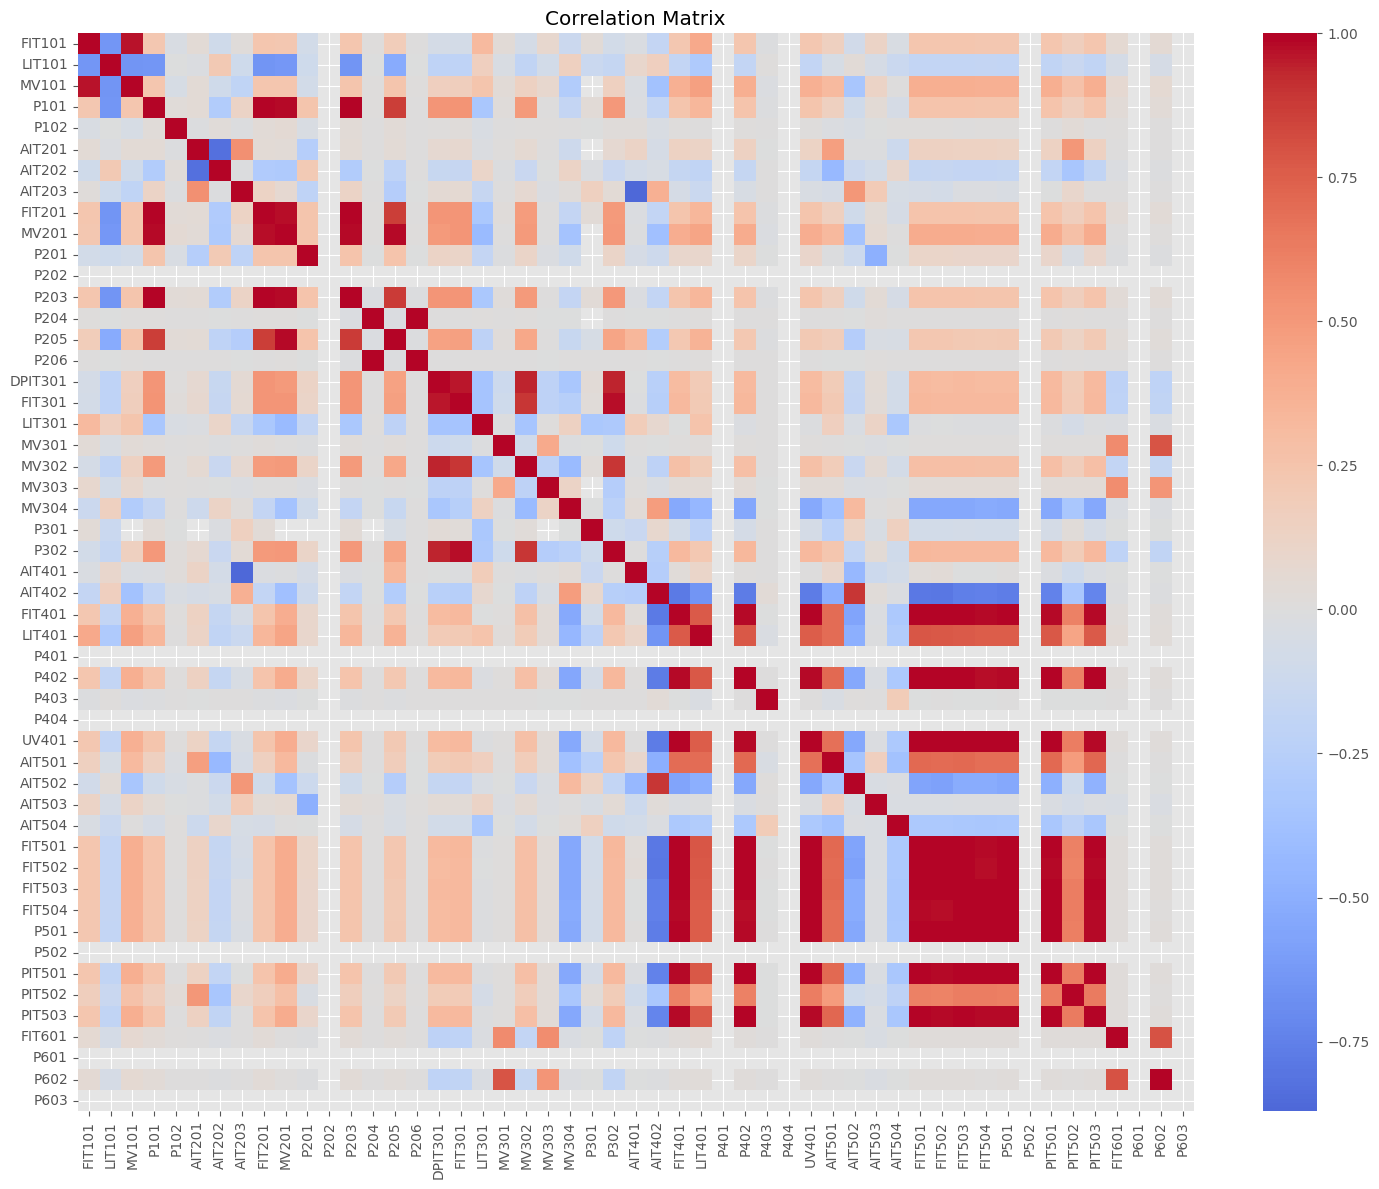

In [28]:
corr = df.select_dtypes("number").corr()

plt.figure(figsize=(18,14))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

### Observation

Highly correlated variables may provide redundant information.

Feature selection will be performed in later stages.

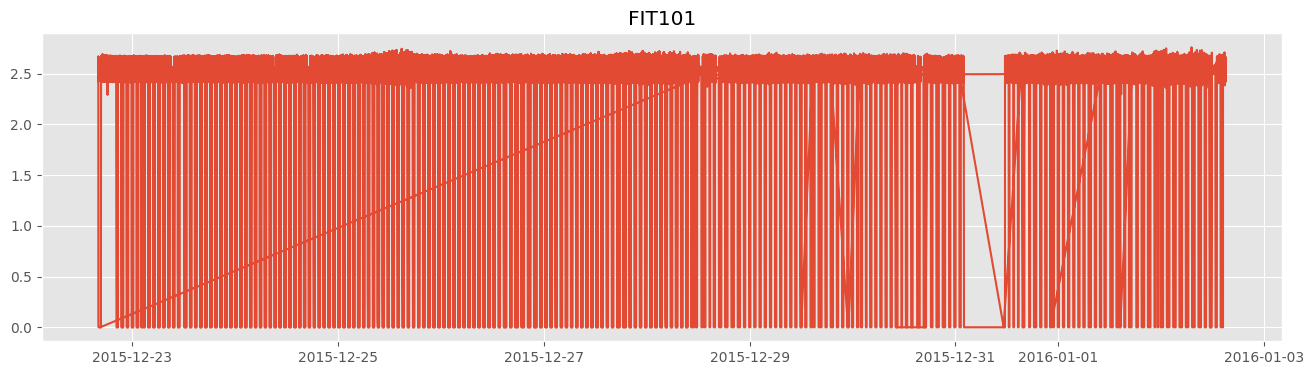

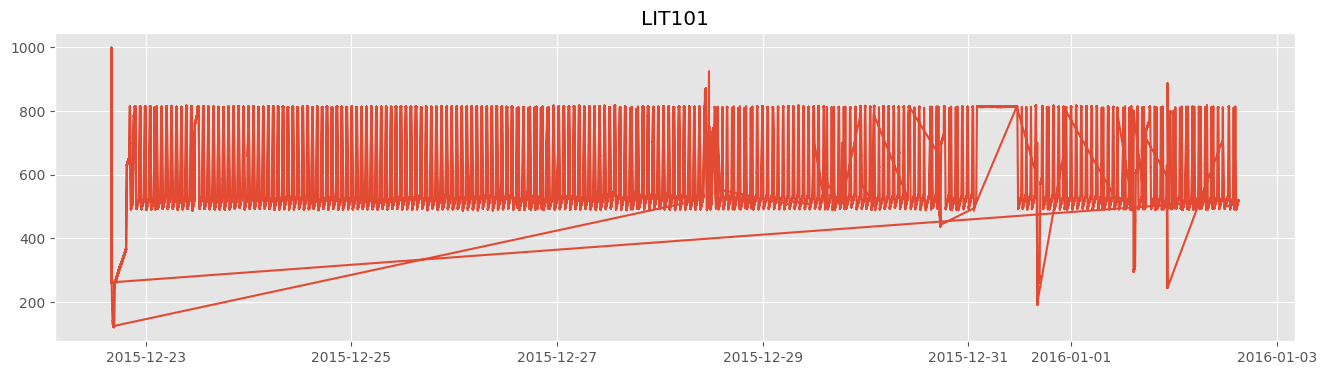

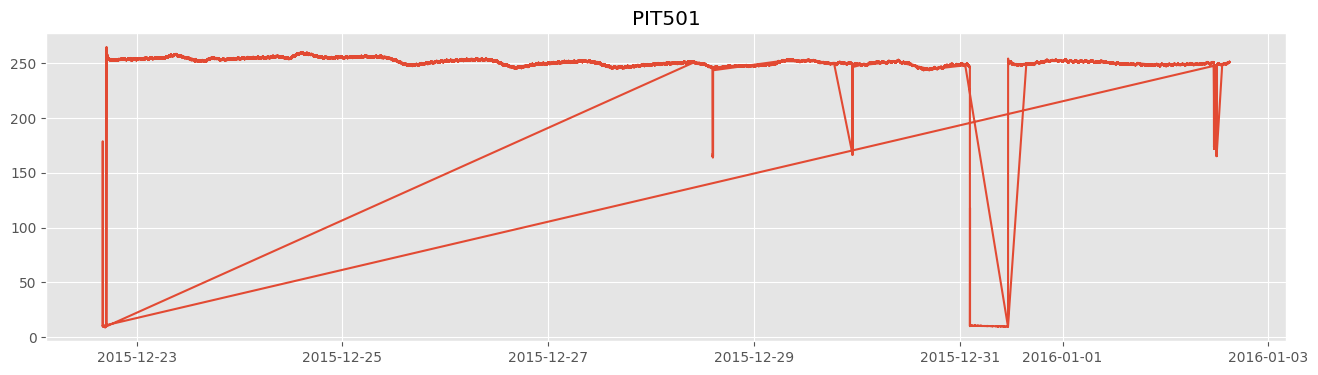

In [29]:
sensor_list = [
"FIT101",
"LIT101",
"PIT501"
]

for sensor in sensor_list:

    plt.figure(figsize=(16,4))

    plt.plot(
        df["Timestamp"],
        df[sensor]
    )

    plt.title(sensor)

    plt.show()

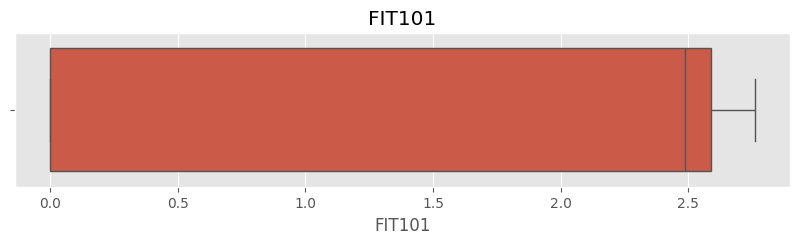

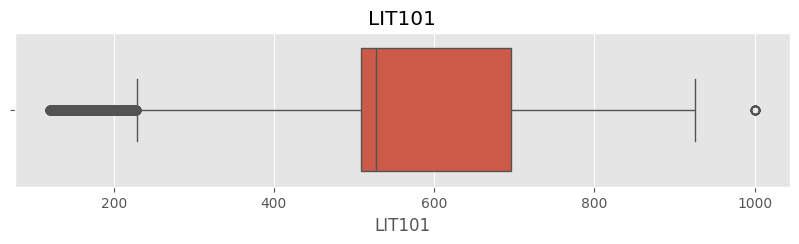

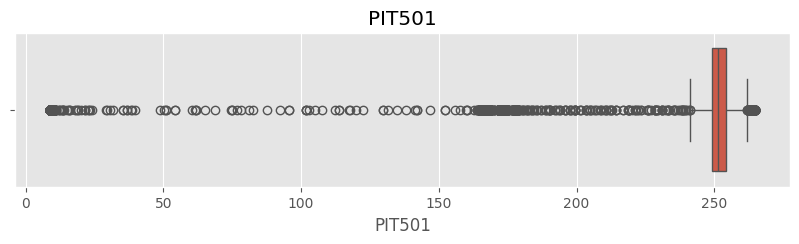

In [30]:
for sensor in sensor_list:

    plt.figure(figsize=(10,2))

    sns.boxplot(
        x=df[sensor]
    )

    plt.title(sensor)

    plt.show()

### Observation

Industrial systems naturally contain outliers.

They may represent faults, operational transitions, or attack scenarios.

Therefore, no outliers will be removed at this stage.

# Industrial Insights

Key findings:

- Flow sensors exhibit stable operating regions with occasional spikes.

- Pressure sensors contain significant variations during abnormal conditions.

- Water quality sensors may be valuable predictors.

- Strong correlations exist among several process variables.

- Outliers are retained because they may represent important abnormal events.

# Summary

This notebook explored the SWaT dataset from an industrial perspective.

The next phase focuses on Feature Engineering and Feature Selection to prepare the data for machine learning models.